# Assignment 4 — CIFAR-10 ConvNet

## AI disclosure


| Field | Your answer |
|-------|-------------|
| Tool / model | Ollama qwen3:1.7b|
| Used for | Discussing different augmentation options and parameters, extending the filter visualisation to all filter indexes|
| Verified how | Allowed model to run and access to the individual filter to extend. All code verified personally.|
| Not used for | Model training and evaluation |

### Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from keras import layers, Sequential, Input, Model, ops
from keras.datasets import cifar10
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from keras.random import uniform
from keras.optimizers import Adam
import tensorflow as tf

# Global Variables
SEED = 1606009
AUG_FACTOR = 0.3
EPOCHS = 50
BATCHSIZE = 128

## 1. Load & Prepare CIFAR-10

In [4]:
class_names = [
    "airplane", "automobile", 
    "bird", "cat", "deer", "dog",
    "frog", "horse", "ship", "truck",
]

# Read dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2643s 16us/step


In [13]:
# Preprocess
x_train = x_train / 255.0
x_test = x_test / 255.0
y_train = y_train.ravel()
y_test = y_test.ravel()

# Validation split 
x_val = x_train[:10000]
y_val = y_train[:10000]
x_train = x_train[10000:]
y_train = y_train[10000:]


In [14]:
print("train:", getattr(x_train, "shape", None), getattr(y_train, "shape", None))
print("val:  ", getattr(x_val, "shape", None), getattr(y_val, "shape", None))
print("test: ", getattr(x_test, "shape", None), getattr(y_test, "shape", None))

train: (30000, 32, 32, 3) (30000,)
val:   (10000, 32, 32, 3) (10000,)
test:  (10000, 32, 32, 3) (10000,)


## 2. Data Augmentation

In [7]:
# Augment data
data_augmentation = Sequential(
    [
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomRotation(AUG_FACTOR, seed=SEED),
        layers.RandomZoom(AUG_FACTOR, seed=SEED),
        layers.RandomContrast(AUG_FACTOR, seed=SEED)
    ],
    name="augmentation"
)

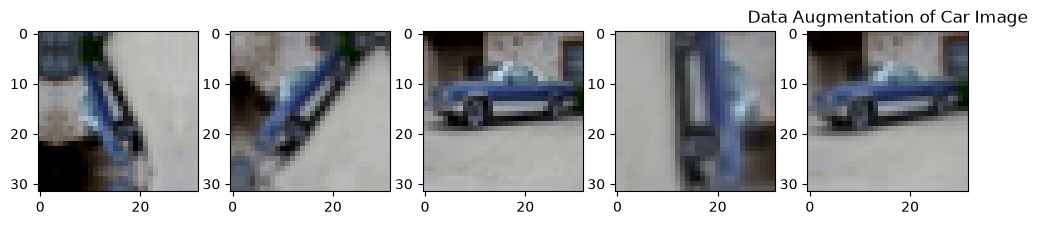

In [8]:
# Visualise a sample image
def preview_augmentation(sample):
    fig, axes = plt.subplots(1, 5, figsize=(12, 3))
    for i in range(5):
        augmented = data_augmentation(sample)
        axes[i].imshow(augmented[0])
    plt.title("Data Augmentation of Car Image", loc="center")
    plt.show()
    
sample = x_train[0][np.newaxis, ...] # One batch
preview_augmentation(sample)

    


## 3. ConvNet Model

In [9]:
INPUT_SHAPE = (32, 32, 3)

def conv2D_layer(x, name, layer_size, conv_size=(3, 3), activation='relu', padding='same'):
    return layers.Conv2D(layer_size, conv_size, activation=activation, padding=padding, name=name)(x)

def maxPool2D_layer(x, name, size=(2, 2)):
    return layers.MaxPool2D(size, name=name)(x)

def batchNorm_layer(x, name):
    return layers.BatchNormalization(name=name)(x)

def dropout_layer(x, name, dropout_rate=0.1):
    return layers.Dropout(dropout_rate, name=name)(x)

def flatten_layer(x, name):
    return layers.Flatten(name=name)(x)

def dense_layer(x, name, layer_size, activation='relu'):
    return layers.Dense(layer_size, activation=activation, name=name)(x)

In [10]:
model = None
inputs = Input(shape=INPUT_SHAPE)
x = data_augmentation(inputs)

for i in range(5):
    for j in range(2):
        conv_number = i * 2 + j + 1
        x = conv2D_layer(x, f'conv2D_{conv_number}', 32*(i+1))
        x = batchNorm_layer(x, f'batchNorm_{conv_number}')
    x = maxPool2D_layer(x, f'maxPool2D_{i + 1}')
    x = dropout_layer(x, f'dropout_{i + 1}')
x = flatten_layer(x, 'flatten_1')
x = dense_layer(x, 'dense_1', 32)

outputs = dense_layer(x, 'dense_output', 10, activation='softmax')
model = Model(inputs, outputs)
model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

print("Model ready:", model is not None)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2D_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchNorm_1                     │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2D_2 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchNorm_2                     │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxPool2D_1 (MaxPooling2D)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2D_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchNorm_3                     │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2D_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchNorm_4                     │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxPool2D_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2D_5 (Conv2D)               │ (None, 8, 8, 96)       │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchNorm_5                     │ (None, 8, 8, 96)       │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2D_6 (Conv2D)               │ (None, 8, 8, 96)       │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchNorm_6                     │ (None, 8, 8, 96)       │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxPool2D_3 (MaxPooling2D)      │ (None, 4, 4, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2D_7 (Conv2D)               │ (None, 4, 4, 128)      │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchNorm_7                     │ (None, 4, 4, 128)      │           51

 Total params: 886,666 (3.38 MB)

 Trainable params: 884,746 (3.38 MB)

 Non-trainable params: 1,920 (7.50 KB)

Model ready: True


## 4. Train & Evaluate

In [11]:
t_acc = None
def get_callbacks():
    return [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    ]

history = model.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size = BATCHSIZE,
    validation_data=(x_val, y_val),
    callbacks=get_callbacks(),
    verbose=1
)

_, t_acc = model.evaluate(x_test, y_test, batch_size=BATCHSIZE)
print(f"Test accuracy %: {100 * t_acc if t_acc is not None else None}")

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 64s 186ms/step - accuracy: 0.2271 - loss: 2.0475 - val_accuracy: 0.2874 - val_loss: 2.0584 - learning_rate: 0.0100
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 57s 184ms/step - accuracy: 0.3118 - loss: 1.8517 - val_accuracy: 0.2829 - val_loss: 1.9628 - learning_rate: 0.0100
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 58s 186ms/step - accuracy: 0.3420 - loss: 1.7711 - val_accuracy: 0.3482 - val_loss: 1.8115 - learning_rate: 0.0100
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 59s 188ms/step - accuracy: 0.3954 - loss: 1.6438 - val_accuracy: 0.4388 - val_loss: 1.5952 - learning_rate: 0.0100
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 58s 187ms/step - accuracy: 0.4379 - loss: 1.5353 - val_accuracy: 0.3601 - val_loss: 1.8626 - learning_rate: 0.0100
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 58s 185ms/step - accuracy: 0.4503 - loss: 1.4981 - val_accuracy: 0.4758 - val_loss: 1.4770 - learning_rate: 0.0100
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 58s 186ms/step - accuracy: 0.4

## 5. Filter Visualisation

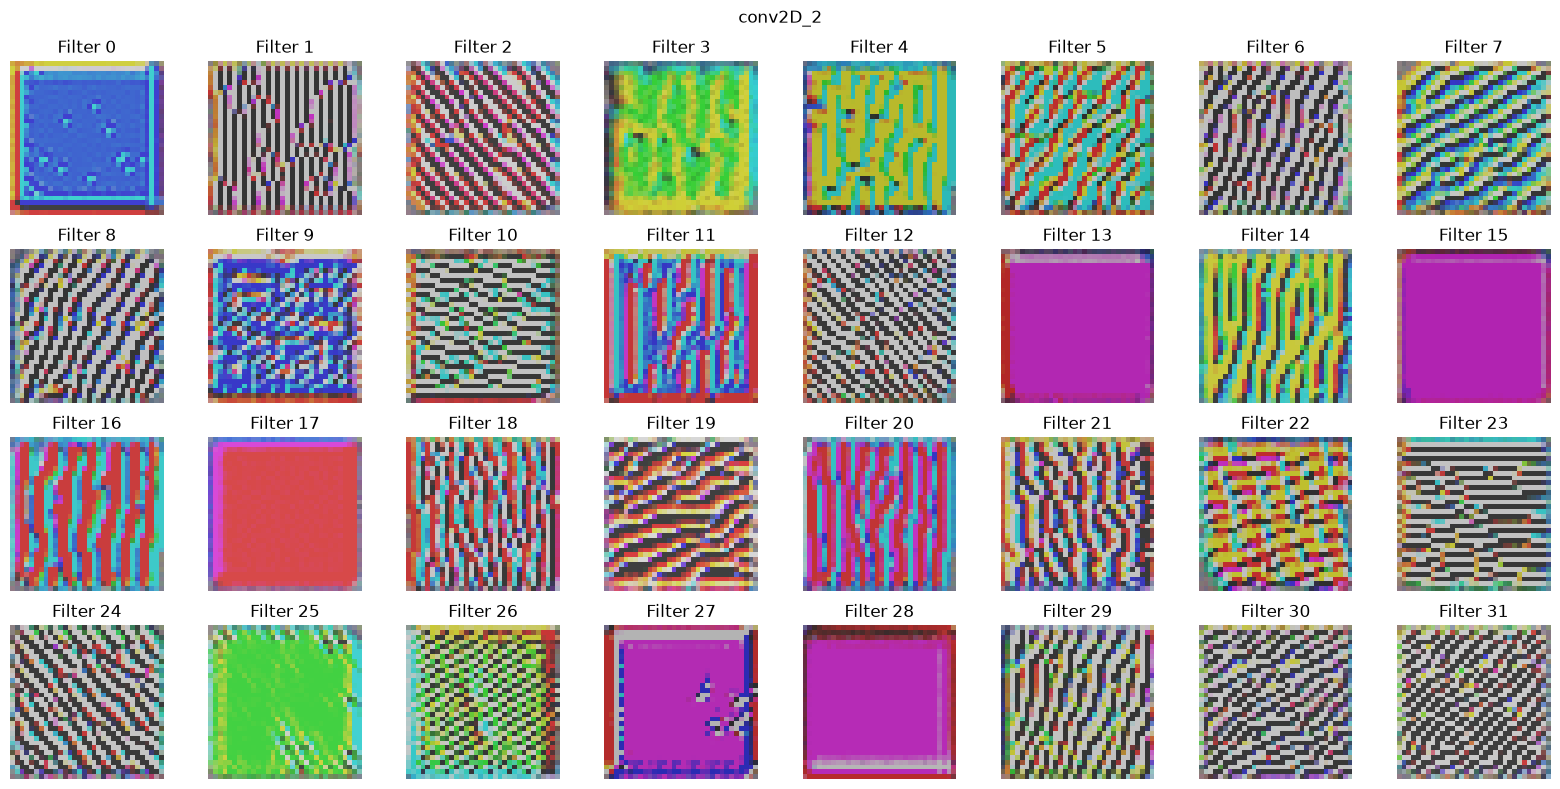

In [15]:
VIS_LAYER = "conv2D_2"
FILTER_INDEX = 20
img_width, img_height = 32, 32

conv_layer = model.get_layer(VIS_LAYER)
feature_extractor = Model(inputs=model.input, outputs=conv_layer.output)

def compute_loss(image, filter_index):
    activation = feature_extractor(image, training=False)
    filter_activation = activation[:, 2:-2, 2:-2, filter_index]
    return ops.mean(filter_activation)

def gradient_ascent_step(image, filter_index, learning_rate):
    with tf.GradientTape() as tape:
        tape.watch(image)
        loss = compute_loss(image, filter_index)
    
    gradients = tape.gradient(loss, image)
    gradients = gradients / (ops.std(gradients) + 1e-8)
    image = image + learning_rate * gradients
    image = ops.clip(image, 0.0, 1.0)
    return image

def generate_filter_pattern(filter_index):
    iterations = 30
    learning_rate = 0.1
    image = uniform(
        minval=0.4,
        maxval=0.6,
        shape=(1, img_width, img_height, 3),
        seed=SEED
    )
    for _ in range(iterations):
        image = gradient_ascent_step(image, filter_index, learning_rate)
    return image[0]
    
def deprocess_image(image):
    image -= ops.mean(image)
    image /= ops.std(image) + 1e-8
    image *= 64
    image += 128
    
    image = ops.clip(image, 0, 255)
    image = ops.cast(image, dtype="uint8")
    return ops.convert_to_numpy(image)
    
def visualise_one_filter_index(filter_index):
    image = generate_filter_pattern(filter_index)
    
    plt.figure(figsize=(4, 4))
    plt.imshow(deprocess_image(image))
    plt.axis("off")
    plt.title(f"{VIS_LAYER}, filter {filter_index}")
    plt.show()

def visualise_all_filter_indexes():
    num_filters = model.get_layer(VIS_LAYER).filters
    columns = 8
    rows = (np.ceil(num_filters / columns)).astype(int)
    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(16, 2 * rows)
    )
    
    for index in range(num_filters):
        image = generate_filter_pattern(index)
        image = deprocess_image(image)
        
        row = index // columns
        column = index % columns
        
        axes[row, column].imshow(image)
        axes[row, column].set_title(f"Filter {index}")
        axes[row, column].axis("off")
        
    for unused in range(num_filters, rows * columns):
        row = unused // columns
        columns = unused % columns
        axes[row, column].axis("off")
        
    fig.suptitle(VIS_LAYER)
    plt.tight_layout()
    plt.show()
    
#visualise_one_filter_index(FILTER_INDEX)
visualise_all_filter_indexes()


## 6. Interpretation

I noticed that the accuarcy tended to plateau around 50% which is higher than randomly guessing but not sufficient for the model. I increased the learning rate and extended the model complexity using the for loops to try reach higher accuracy.

Filter 25 is mainly green compared to Filter 2 which are diagnonal stripes. Filter 25 is likely detecting the colour green for the background of the images with grass/fields. As the images of planes and birds are likely in the sky (blue) this helps the model detect ground based images. Filter 2 is detecting straight edges at different heights on an angle across the filter. As the filter moves across the whole of the image, 25 will be detecting any green in the image in any section, as none of the target things in the images are green, I assume it is for the background. The filter is almost entirely green with diagnonal edge lines surrounding so the filter is likely identifying both the green colours and edges outside of the green pixels within the whole image.